In [ ]:

import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


In [3]:
def parse_cst_block_file(path):
    """Parse CST text export with repeated headers and return blocks keyed by ratio."""
    blocks = {}
    current_ratio = None
    current_x = []
    current_y = []

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                if current_ratio is not None and current_x:
                    blocks[current_ratio] = {
                        "x": np.array(current_x, dtype=float),
                        "y": np.array(current_y, dtype=float),
                    }

                m = re.search(r"Ratio\s*=\s*([0-9]*\.?[0-9]+)", line)
                if m is None:
                    current_ratio = None
                    current_x = []
                    current_y = []
                    continue

                current_ratio = float(m.group(1))
                current_x = []
                current_y = []
                continue

            if line.startswith("#"):
                continue

            if current_ratio is None:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    if current_ratio is not None and current_x:
        blocks[current_ratio] = {
            "x": np.array(current_x, dtype=float),
            "y": np.array(current_y, dtype=float),
        }

    return blocks

ratio=0.100  G=1.605928e-02  eta_E0=1.605928e-02  Emax=7.828590e-01  eta_Emax=2.051363e-02  phi=-0.4468 rad (-25.60 deg)
ratio=0.200  G=3.608421e-02  eta_E0=3.608421e-02  Emax=8.031123e-01  eta_Emax=4.493046e-02  phi=-0.4614 rad (-26.43 deg)
ratio=0.300  G=5.699409e-02  eta_E0=5.699409e-02  Emax=8.260160e-01  eta_Emax=6.899878e-02  phi=-0.4748 rad (-27.20 deg)
ratio=0.400  G=7.581002e-02  eta_E0=7.581002e-02  Emax=8.491501e-01  eta_Emax=8.927753e-02  phi=-0.4920 rad (-28.19 deg)
ratio=0.500  G=8.892862e-02  eta_E0=8.892862e-02  Emax=8.670353e-01  eta_Emax=1.025663e-01  phi=-0.5109 rad (-29.27 deg)
ratio=0.600  G=9.482003e-02  eta_E0=9.482003e-02  Emax=8.734066e-01  eta_Emax=1.085635e-01  phi=-0.5314 rad (-30.45 deg)
ratio=0.700  G=9.164076e-02  eta_E0=9.164076e-02  Emax=8.607298e-01  eta_Emax=1.064687e-01  phi=-0.5537 rad (-31.73 deg)
ratio=0.800  G=7.848842e-02  eta_E0=7.848842e-02  Emax=8.231391e-01  eta_Emax=9.535256e-02  phi=-0.5786 rad (-33.15 deg)
ratio=0.900  G=5.311530e-02  eta

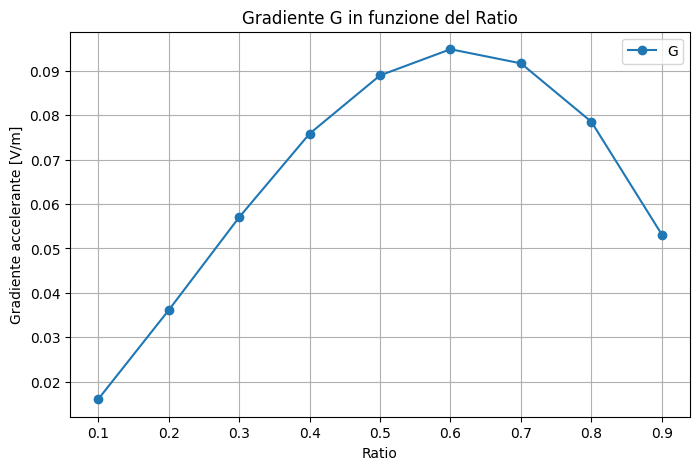

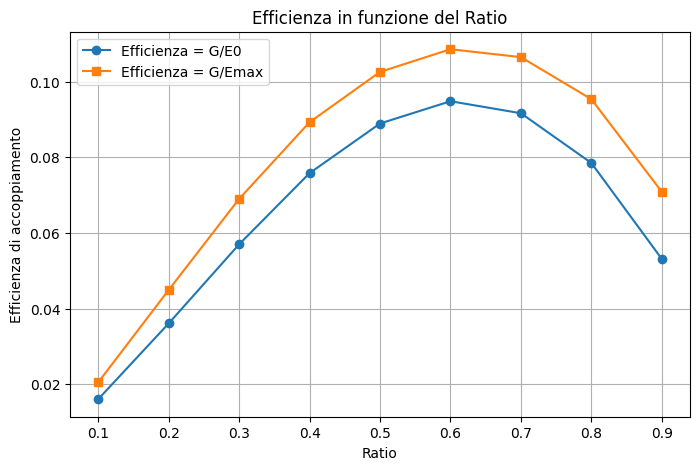

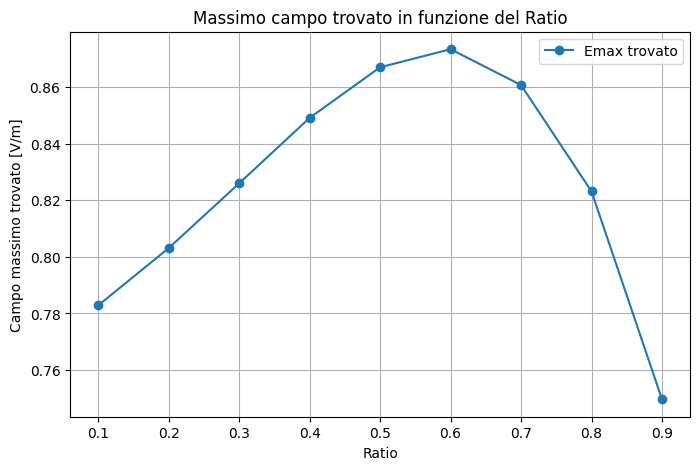

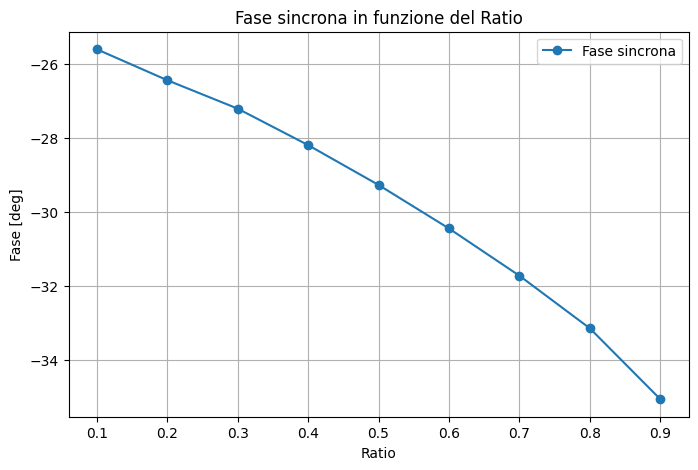

In [23]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

cartella = Path("SIC_P_10um/n_3")
if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")



# Parametri (x e lambda_p sono in um)
lambda_p = 3*10 * 0.01459  # periodo della struttura in um (145.9 nm)
n = 1
E0_const = 1.0  # V/m: ampiezza della plane wave impostata in CST

im_blocks = parse_cst_block_file(cartella / "A_Im.txt")
re_blocks = parse_cst_block_file(cartella / "A_Real.txt")

common_ratios = sorted(set(im_blocks.keys()) & set(re_blocks.keys()))
if not common_ratios:
    raise ValueError("Nessun ratio in comune tra A_Im.txt e A_Real.txt")

G = np.zeros(len(common_ratios))
efficiency = np.zeros(len(common_ratios))
efficiency_max = np.zeros(len(common_ratios))
E_max_found = np.zeros(len(common_ratios))
phi_rad = np.zeros(len(common_ratios))
phi_deg = np.zeros(len(common_ratios))

for i, ratio_val in enumerate(common_ratios):
    x_im = im_blocks[ratio_val]["x"]
    x_re = re_blocks[ratio_val]["x"]
    im_ex = im_blocks[ratio_val]["y"]
    re_ex = re_blocks[ratio_val]["y"]

    if len(x_im) != len(x_re) or np.max(np.abs(x_im - x_re)) > 1e-12:
        raise ValueError(f"Asse x non allineato per ratio={ratio_val}")

    x = x_im
    Ex = re_ex + 1j * im_ex
    phase = np.exp(-1j * 2 * np.pi * n * x / lambda_p)

    L = x[-1] - x[0]
    complex_grad = np.trapezoid(Ex * phase, x) / L

    G[i] = np.abs(complex_grad)
    phi_rad[i] = np.angle(complex_grad)
    phi_deg[i] = np.degrees(phi_rad[i])

    E_max_found[i] = np.max(np.abs(Ex))
    efficiency[i] = G[i] / E0_const
    efficiency_max[i] = G[i] / E_max_found[i]

    print(
        f"ratio={ratio_val:.3f}  G={G[i]:.6e}  eta_E0={efficiency[i]:.6e}  "
        f"Emax={E_max_found[i]:.6e}  eta_Emax={efficiency_max[i]:.6e}  "
        f"phi={phi_rad[i]:+.4f} rad ({phi_deg[i]:+.2f} deg)"
    )

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, G, marker="o", label="G")
plt.xlabel("Ratio")
plt.ylabel("Gradiente accelerante [V/m]")
plt.title("Gradiente G in funzione del Ratio")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, efficiency, marker="o", label="Efficienza = G/E0")
plt.plot(common_ratios, efficiency_max, marker="s", label="Efficienza = G/Emax")
plt.xlabel("Ratio")
plt.ylabel("Efficienza di accoppiamento")
plt.title("Efficienza in funzione del Ratio")
plt.grid(True)
plt.legend()
plt.savefig(cartella / "A_efficiency_vs_ratio.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, E_max_found, marker="o", label="Emax trovato")
plt.xlabel("Ratio")
plt.ylabel("Campo massimo trovato [V/m]")
plt.title("Massimo campo trovato in funzione del Ratio")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_ratios, phi_deg, marker="o", label="Fase sincrona")
plt.xlabel("Ratio")
plt.ylabel("Fase [deg]")
plt.title("Fase sincrona in funzione del Ratio")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from pathlib import Path
import numpy as np


def read_cst_field_file(path):
    """Read CST field export: keep first 2 header lines and parse numeric table."""
    path = Path(path)

    with path.open("r", encoding="utf-8") as f:
        header1 = f.readline().rstrip("\n")
        header2 = f.readline().rstrip("\n")

    data = np.loadtxt(path, skiprows=2)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] < 9:
        raise ValueError(f"{path.name}: attese almeno 9 colonne, trovate {data.shape[1]}")

    return header1, header2, data


def write_cst_field_file(path, header1, header2, data):
    """Write CST-like text file preserving header and numeric columns."""
    path = Path(path)

    with path.open("w", encoding="utf-8", newline="\n") as f:
        f.write(header1 + "\n")
        f.write(header2 + "\n")

        # 3 colonne coordinate + 6 colonne di campo
        for row in data:
            f.write(
                f"{row[0]:15.6f}"
                f"{row[1]:15.6f}"
                f"{row[2]:15.6f}"
                f"{row[3]:16.8e}"
                f"{row[4]:16.8e}"
                f"{row[5]:16.8e}"
                f"{row[6]:16.8e}"
                f"{row[7]:16.8e}"
                f"{row[8]:16.8e}\n"
            )


# File input: file1 e' il riferimento
file1 = Path("SIC_P_10um/n_3/Campo_3Dtxt")
file2 = Path("SIC_P_10um/n_3/Campo_3D_Alto.txt")
out_file = Path("SIC_P_10um/n_3/Field_completo_somma.txt")

h1_1, h2_1, data1 = read_cst_field_file(file1)
h1_2, h2_2, data2 = read_cst_field_file(file2)

if data1.shape[1] < 9 or data2.shape[1] < 9:
    raise ValueError("Entrambi i file devono avere almeno 9 colonne (x y z + 6 componenti campo)")

# Coordinate come chiave esatta (nessuna tolleranza)
xyz1 = data1[:, :3]
xyz2 = data2[:, :3]
keys1 = [tuple(row) for row in xyz1]
keys2 = [tuple(row) for row in xyz2]

if len(set(keys1)) != len(keys1):
    raise ValueError(f"Coordinate duplicate in {file1.name}")
if len(set(keys2)) != len(keys2):
    raise ValueError(f"Coordinate duplicate in {file2.name}")

# Cerca in file2 le coordinate presenti in file1, indipendentemente dall'ordine
index2 = {k: i for i, k in enumerate(keys2)}
missing = [k for k in keys1 if k not in index2]
if missing:
    esempio = missing[0]
    raise ValueError(
        f"Coordinate mancanti in {file2.name}: {len(missing)} su {len(keys1)}. "
        f"Esempio mancante: x={esempio[0]}, y={esempio[1]}, z={esempio[2]}"
    )

aligned2_idx = [index2[k] for k in keys1]
aligned2 = data2[aligned2_idx]

# Somma componente per componente: ExRe ExIm EyRe EyIm EzRe EzIm (colonne 3:9)
out = data1.copy()
out[:, 3:9] = data1[:, 3:9] + aligned2[:, 3:9]

# Coordinate mantenute da file1 (riferimento)
out[:, :3] = data1[:, :3]

# Scrive con header del primo file
write_cst_field_file(out_file, h1_1, h2_1, out)

print(f"Creato: {out_file}")
print(f"Righe sommate: {len(out)}")
print(f"Righe extra in {file2.name} (ignorate): {len(data2) - len(data1)}")
print("Prime 3 righe (x y z ExRe ExIm EyRe EyIm EzRe EzIm):")
print(out[:3, :9])

Creato: Field_completo_20n_somma.txt
Righe sommate: 557232
Righe extra in Field_completo_20n_Alto.txt (ignorate): 0
Prime 3 righe (x y z ExRe ExIm EyRe EyIm EzRe EzIm):
[[-2.32500000e+02  0.00000000e+00 -2.27000000e+03 -1.93471825e+00
   2.46640500e-02  4.98109080e-04  8.66336440e-05 -1.11948938e-03
   5.13652000e-05]
 [-2.12500000e+02  0.00000000e+00 -2.27000000e+03 -1.93318290e+00
   2.46295900e-02 -3.93027900e-04  8.88865753e-05 -1.24089859e-04
   4.63212090e-05]
 [-1.92500000e+02  0.00000000e+00 -2.27000000e+03 -1.93400115e+00
   2.46426200e-02  1.25714105e-04 -2.70980486e-05 -2.90533420e-04
   1.43960060e-05]]


H=200  G=9.667241e-02  eta_E0=9.667241e-02  Emax=8.885063e-01  eta_Emax=1.088033e-01  phi=-0.5205 rad (-29.82 deg)
H=300  G=8.807036e-02  eta_E0=8.807036e-02  Emax=8.101176e-01  eta_Emax=1.087131e-01  phi=-0.5685 rad (-32.58 deg)
H=400  G=8.115821e-02  eta_E0=8.115821e-02  Emax=7.449531e-01  eta_Emax=1.089441e-01  phi=-0.5993 rad (-34.34 deg)
H=500  G=7.590047e-02  eta_E0=7.590047e-02  Emax=7.010104e-01  eta_Emax=1.082730e-01  phi=-0.6157 rad (-35.28 deg)
H=600  G=7.196753e-02  eta_E0=7.196753e-02  Emax=6.625507e-01  eta_Emax=1.086219e-01  phi=-0.6228 rad (-35.68 deg)
H=700  G=6.942353e-02  eta_E0=6.942353e-02  Emax=6.424117e-01  eta_Emax=1.080671e-01  phi=-0.6257 rad (-35.85 deg)
H=800  G=6.749764e-02  eta_E0=6.749764e-02  Emax=6.238769e-01  eta_Emax=1.081906e-01  phi=-0.6237 rad (-35.74 deg)
H=900  G=6.651661e-02  eta_E0=6.651661e-02  Emax=6.159997e-01  eta_Emax=1.079816e-01  phi=-0.6276 rad (-35.96 deg)
H=1000  G=6.606174e-02  eta_E0=6.606174e-02  Emax=6.144063e-01  eta_Emax=1.07521

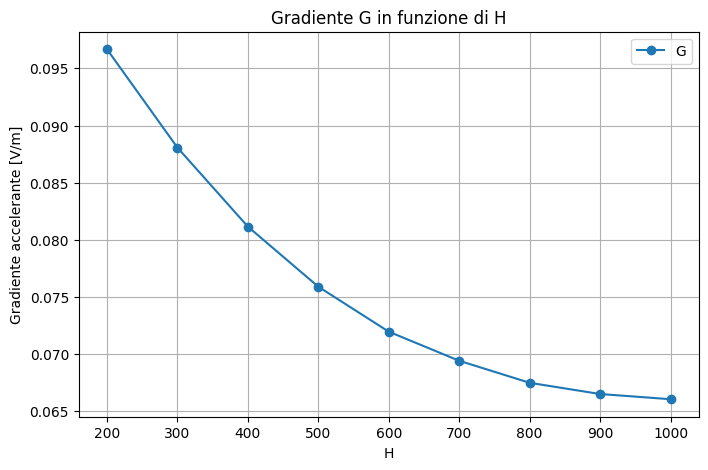

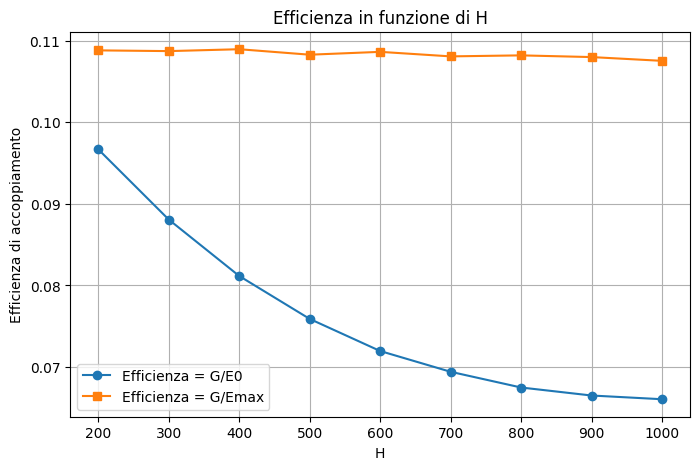

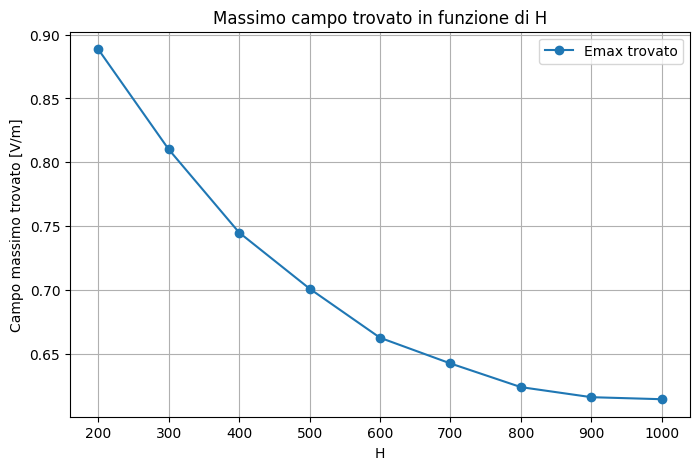

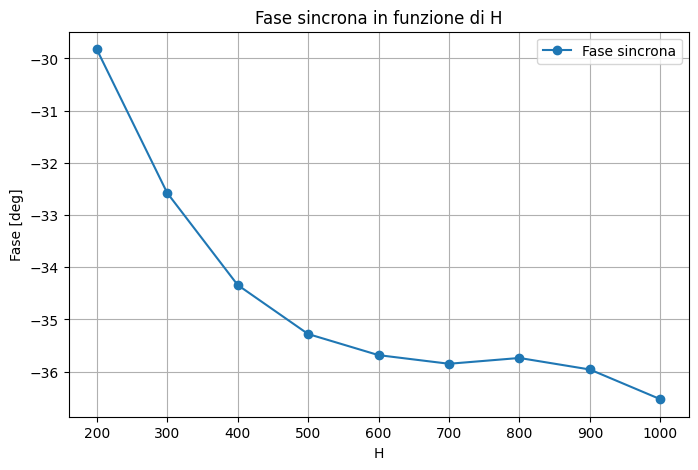

In [25]:
import re
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt


def parse_cst_block_file_by_param(path, param_name="H"):
    """Parse CST text export with repeated headers and return blocks keyed by param_name."""
    blocks = {}
    current_param = None
    current_x = []
    current_y = []

    pattern = re.compile(rf"{re.escape(param_name)}\s*=\s*([0-9]*\.?[0-9]+)")

    with open(path, "r", encoding="utf-8") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith("#Parameters"):
                if current_param is not None and current_x:
                    blocks[current_param] = {
                        "x": np.array(current_x, dtype=float),
                        "y": np.array(current_y, dtype=float),
                    }

                m = pattern.search(line)
                if m is None:
                    current_param = None
                    current_x = []
                    current_y = []
                    continue

                current_param = float(m.group(1))
                current_x = []
                current_y = []
                continue

            if line.startswith("#"):
                continue

            if current_param is None:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            try:
                x_val = float(parts[0])
                y_val = float(parts[1])
            except ValueError:
                continue

            current_x.append(x_val)
            current_y.append(y_val)

    if current_param is not None and current_x:
        blocks[current_param] = {
            "x": np.array(current_x, dtype=float),
            "y": np.array(current_y, dtype=float),
        }

    return blocks


cartella = Path("SIC_P_10um/n_3")
if not cartella.exists():
    raise FileNotFoundError(f"Cartella non trovata: {cartella.resolve()}")

# Parametri (x e lambda_p sono in um)
lambda_p = 3 * 10 * 0.01459
n = 1
E0_const = 1.0

im_blocks = parse_cst_block_file_by_param(cartella / "H_Im.txt", param_name="H")
re_blocks = parse_cst_block_file_by_param(cartella / "H_Real.txt", param_name="H")

common_H = sorted(set(im_blocks.keys()) & set(re_blocks.keys()))
if not common_H:
    raise ValueError("Nessun valore di H in comune tra H_Im.txt e H_Real.txt")

G = np.zeros(len(common_H))
efficiency = np.zeros(len(common_H))
efficiency_max = np.zeros(len(common_H))
E_max_found = np.zeros(len(common_H))
phi_rad = np.zeros(len(common_H))
phi_deg = np.zeros(len(common_H))

for i, h_val in enumerate(common_H):
    x_im = im_blocks[h_val]["x"]
    x_re = re_blocks[h_val]["x"]
    im_ex = im_blocks[h_val]["y"]
    re_ex = re_blocks[h_val]["y"]

    if len(x_im) != len(x_re) or np.max(np.abs(x_im - x_re)) > 1e-12:
        raise ValueError(f"Asse x non allineato per H={h_val}")

    x = x_im
    Ex = re_ex + 1j * im_ex
    phase = np.exp(-1j * 2 * np.pi * n * x / lambda_p)

    L = x[-1] - x[0]
    complex_grad = np.trapezoid(Ex * phase, x) / L

    G[i] = np.abs(complex_grad)
    phi_rad[i] = np.angle(complex_grad)
    phi_deg[i] = np.degrees(phi_rad[i])

    E_max_found[i] = np.max(np.abs(Ex))
    efficiency[i] = G[i] / E0_const
    efficiency_max[i] = G[i] / E_max_found[i]

    print(
        f"H={h_val:.6g}  G={G[i]:.6e}  eta_E0={efficiency[i]:.6e}  "
        f"Emax={E_max_found[i]:.6e}  eta_Emax={efficiency_max[i]:.6e}  "
        f"phi={phi_rad[i]:+.4f} rad ({phi_deg[i]:+.2f} deg)"
    )

plt.figure(figsize=(8, 5))
plt.plot(common_H, G, marker="o", label="G")
plt.xlabel("H")
plt.ylabel("Gradiente accelerante [V/m]")
plt.title("Gradiente G in funzione di H")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, efficiency, marker="o", label="Efficienza = G/E0")
plt.plot(common_H, efficiency_max, marker="s", label="Efficienza = G/Emax")
plt.xlabel("H")
plt.ylabel("Efficienza di accoppiamento")
plt.title("Efficienza in funzione di H")
plt.grid(True)
plt.legend()
plt.savefig(cartella / "H_efficiency_vs_H.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, E_max_found, marker="o", label="Emax trovato")
plt.xlabel("H")
plt.ylabel("Campo massimo trovato [V/m]")
plt.title("Massimo campo trovato in funzione di H")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(common_H, phi_deg, marker="o", label="Fase sincrona")
plt.xlabel("H")
plt.ylabel("Fase [deg]")
plt.title("Fase sincrona in funzione di H")
plt.grid(True)
plt.legend()
plt.show()